In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00


In [ ]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"
ZIP_PATH = f"{PROJECT_DIR}/transformed_datasets/WilderPerson/gaussian_faceblur_dataset.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/gaussian_faceblur_dataset.zip")
print("Copied zip to Colab VM")

Copied zip to Colab VM


In [ ]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/gaussian_faceblur_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Unzipped dataset


In [ ]:
!ls /content/final-year-research/dataset/

data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


In [ ]:
import yaml

yaml_path = "/content/final-year-research/WilderPerson_colab.yaml"

data = {
    "path": "/content/final-year-research/dataset",
    "train": "/content/final-year-research/dataset/train/images",
    "val": "/content/final-year-research/dataset/valid/images",
    "names": {
        0: "pedestrian",
        1: "other"
    }
}

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("YAML fixed! Now defining 2 classes (0 and 1).")

FileNotFoundError: [Errno 2] No such file or directory: '/content/final-year-research/WilderPerson_colab.yaml'

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU name: Tesla T4


In [ ]:
# This deletes the cache files so YOLO re-scans the labels
!rm -f /content/final-year-research/dataset/train/labels.cache
!rm -f /content/final-year-research/dataset/valid/labels.cache

In [ ]:
!find /content/final-year-research -maxdepth 3 -type d

/content/final-year-research
/content/final-year-research/dataset
/content/final-year-research/dataset/valid
/content/final-year-research/dataset/valid/images
/content/final-year-research/dataset/valid/labels
/content/final-year-research/dataset/train
/content/final-year-research/dataset/train/images
/content/final-year-research/dataset/train/labels


In [ ]:
import glob

ROOT = "/content/final-year-research/dataset"

print("train images:", len(glob.glob(ROOT + "/train/images/*")))
print("train labels:", len(glob.glob(ROOT + "/train/labels/*")))
print("valid images:", len(glob.glob(ROOT + "/valid/images/*")))
print("valid labels:", len(glob.glob(ROOT + "/valid/labels/*")))

train images: 10098
train labels: 10098
valid images: 3284
valid labels: 3284


In [ ]:
import yaml

yaml_path = "/content/final-year-research/WilderPerson_colab.yaml"

data = {
    "path": "/content/final-year-research/dataset",
    "train": "/content/final-year-research/dataset/train/images",
    "val": "/content/final-year-research/dataset/valid/images",
    "names": {
        0: "pedestrian",
        1: "other"
    }
}

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("YAML fixed! Now defining 2 classes (0 and 1).")

YAML fixed! Now defining 2 classes (0 and 1).


In [ ]:
# This deletes the cache files so YOLO re-scans the labels
!rm -f /content/final-year-research/dataset/train/labels.cache
!rm -f /content/final-year-research/dataset/valid/labels.cache

In [ ]:
!yolo detect train \
  model=yolov8s.pt \
  data="/content/final-year-research/WilderPerson_colab.yaml" \
  epochs=50 \
  imgsz=640 \
  batch=16 \
  device=0 \
  patience=20 \
  project="/content/drive/MyDrive/final-year-research/runs" \
  name="wilderperson_faceblur_research_v1"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final-year-research/WilderPerson_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv

In [ ]:
!yolo detect train \
resume=True \
model="/content/drive/MyDrive/final-year-research/runs/wilderperson_research_v1/weights/last.pt"

/bin/bash: line 1: yolo: command not found


In [ ]:
!yolo detect train \
  model="/content/drive/MyDrive/final-year-research/runs/wilderperson_faceblur_research_v1/weights/last.pt" \
  data="/content/WilderPerson_colab.yaml" \
  epochs=50 \
  imgsz=640 \
  batch=16 \
  device=0 \
  patience=20 \
  project="/content/drive/MyDrive/final-year-research/runs" \
  name="wilderperson_faceblur_research_v1" \
  resume=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final-year-research/WilderPerson_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv

Visualizing Baseline Model Results

In [ ]:
RUN_DIR = "/content/drive/MyDrive/final-year-research/runs/wilderperson_faceblur_research_v1"

Showing: BoxPR_curve.png


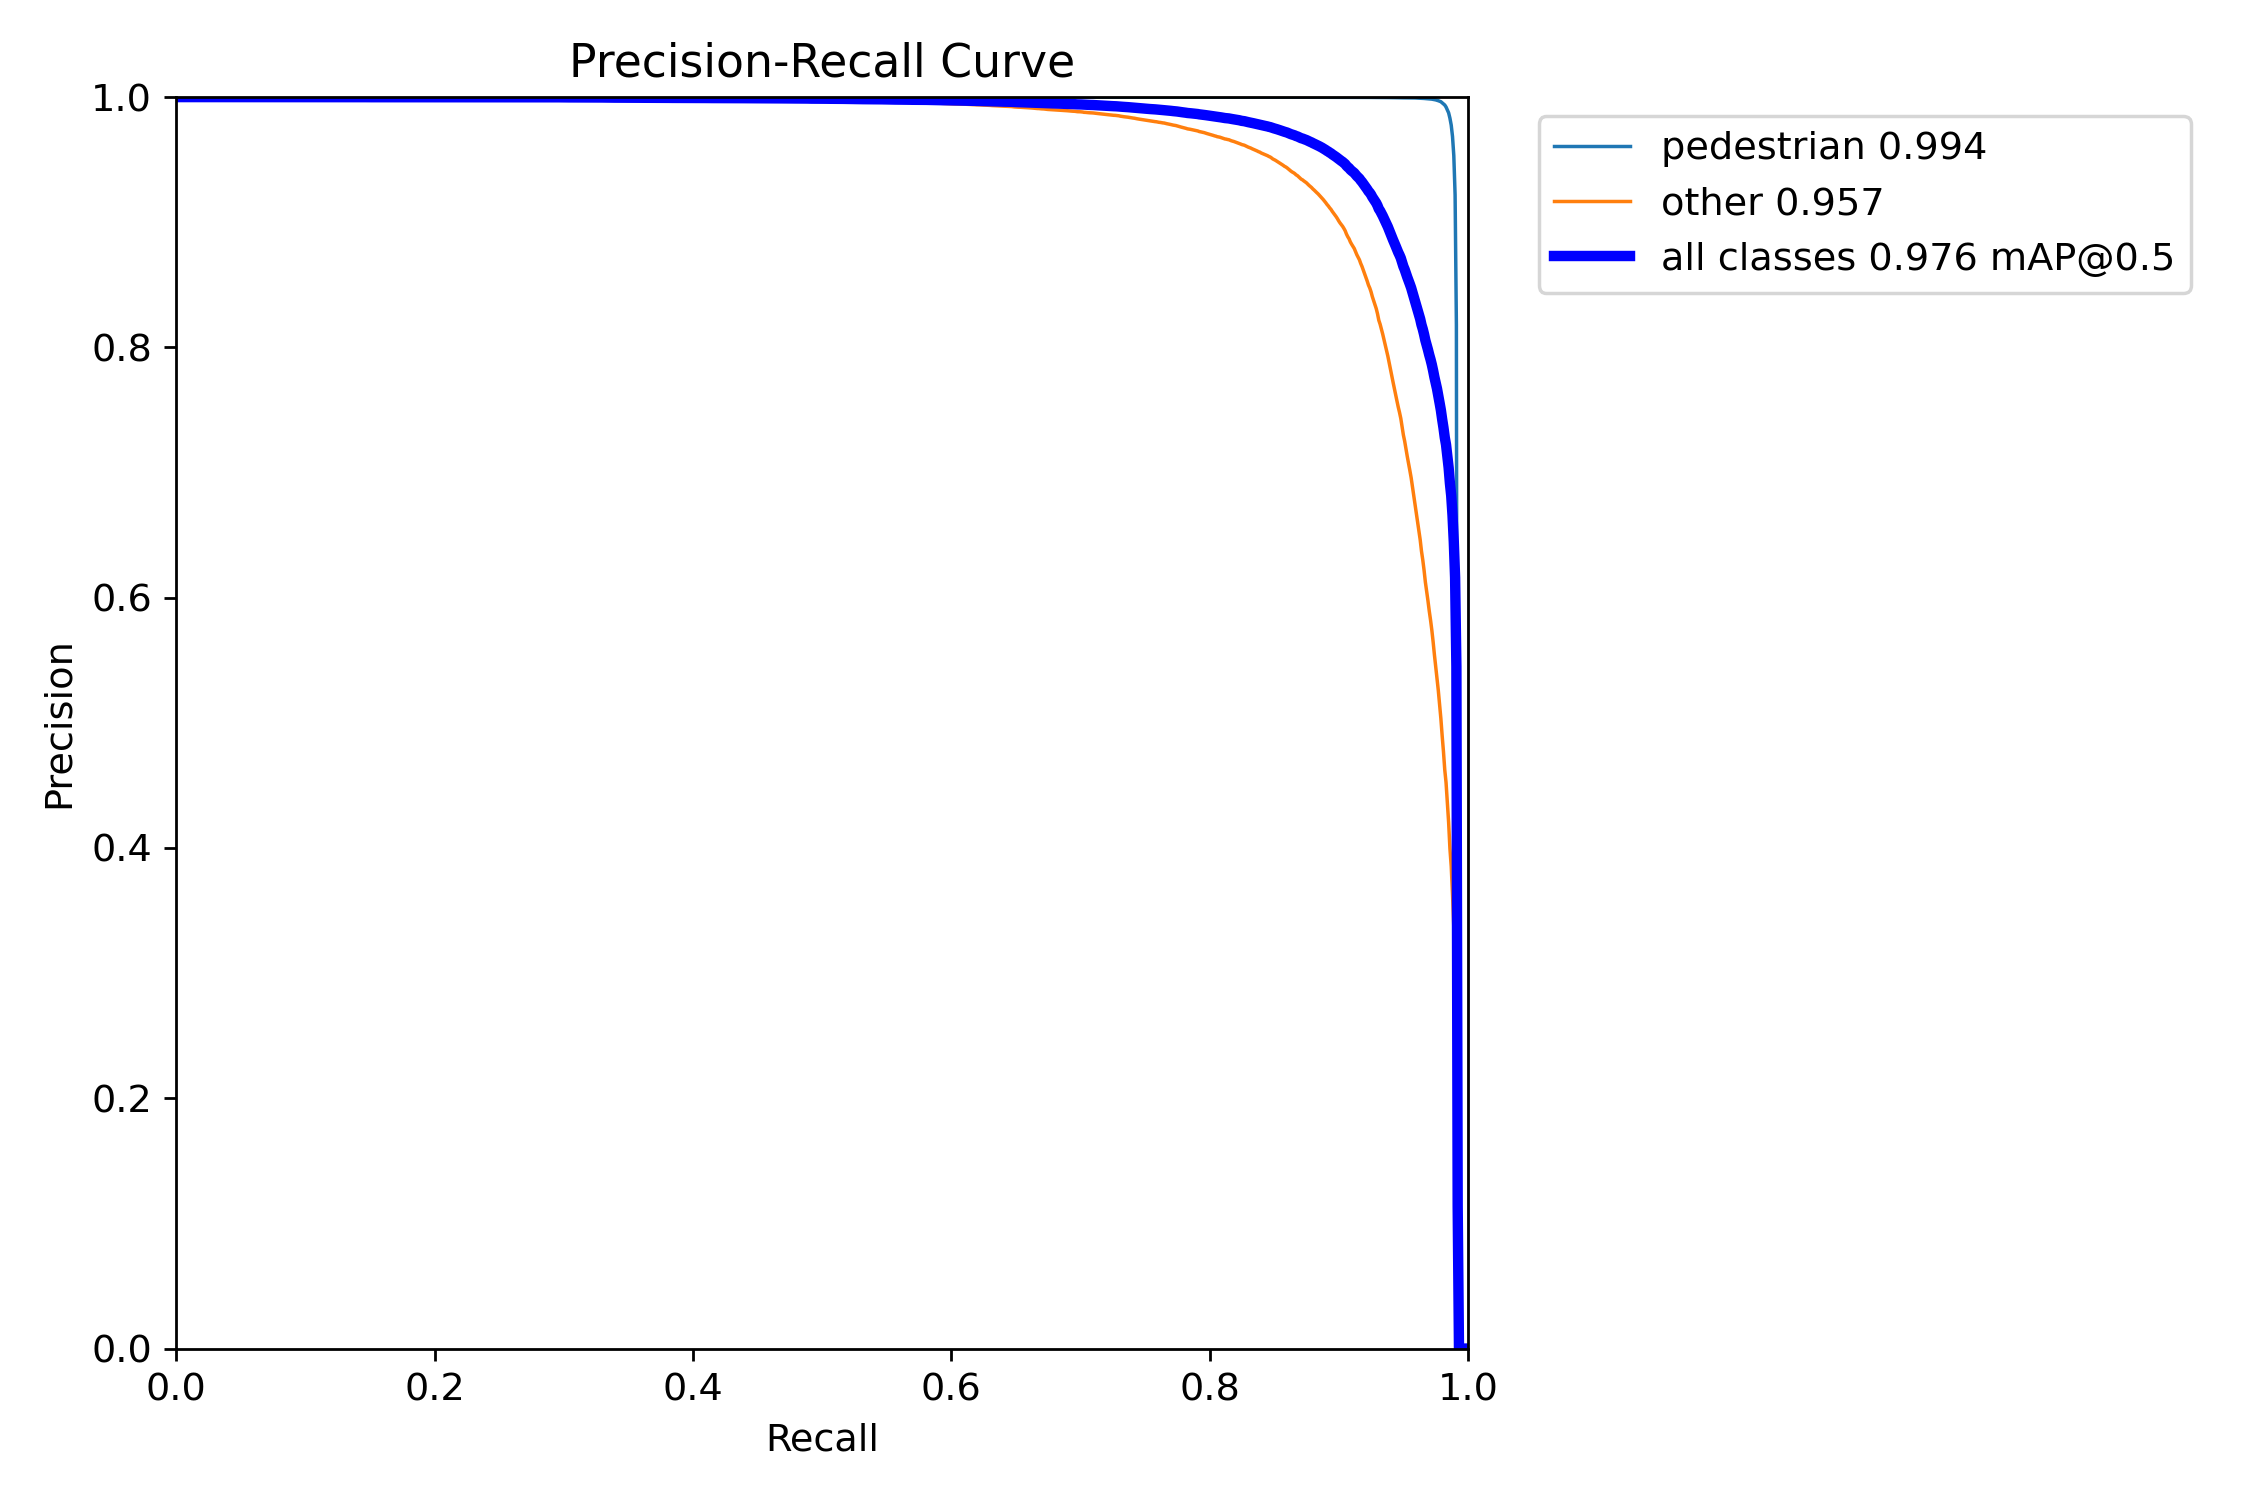

Showing: BoxF1_curve.png


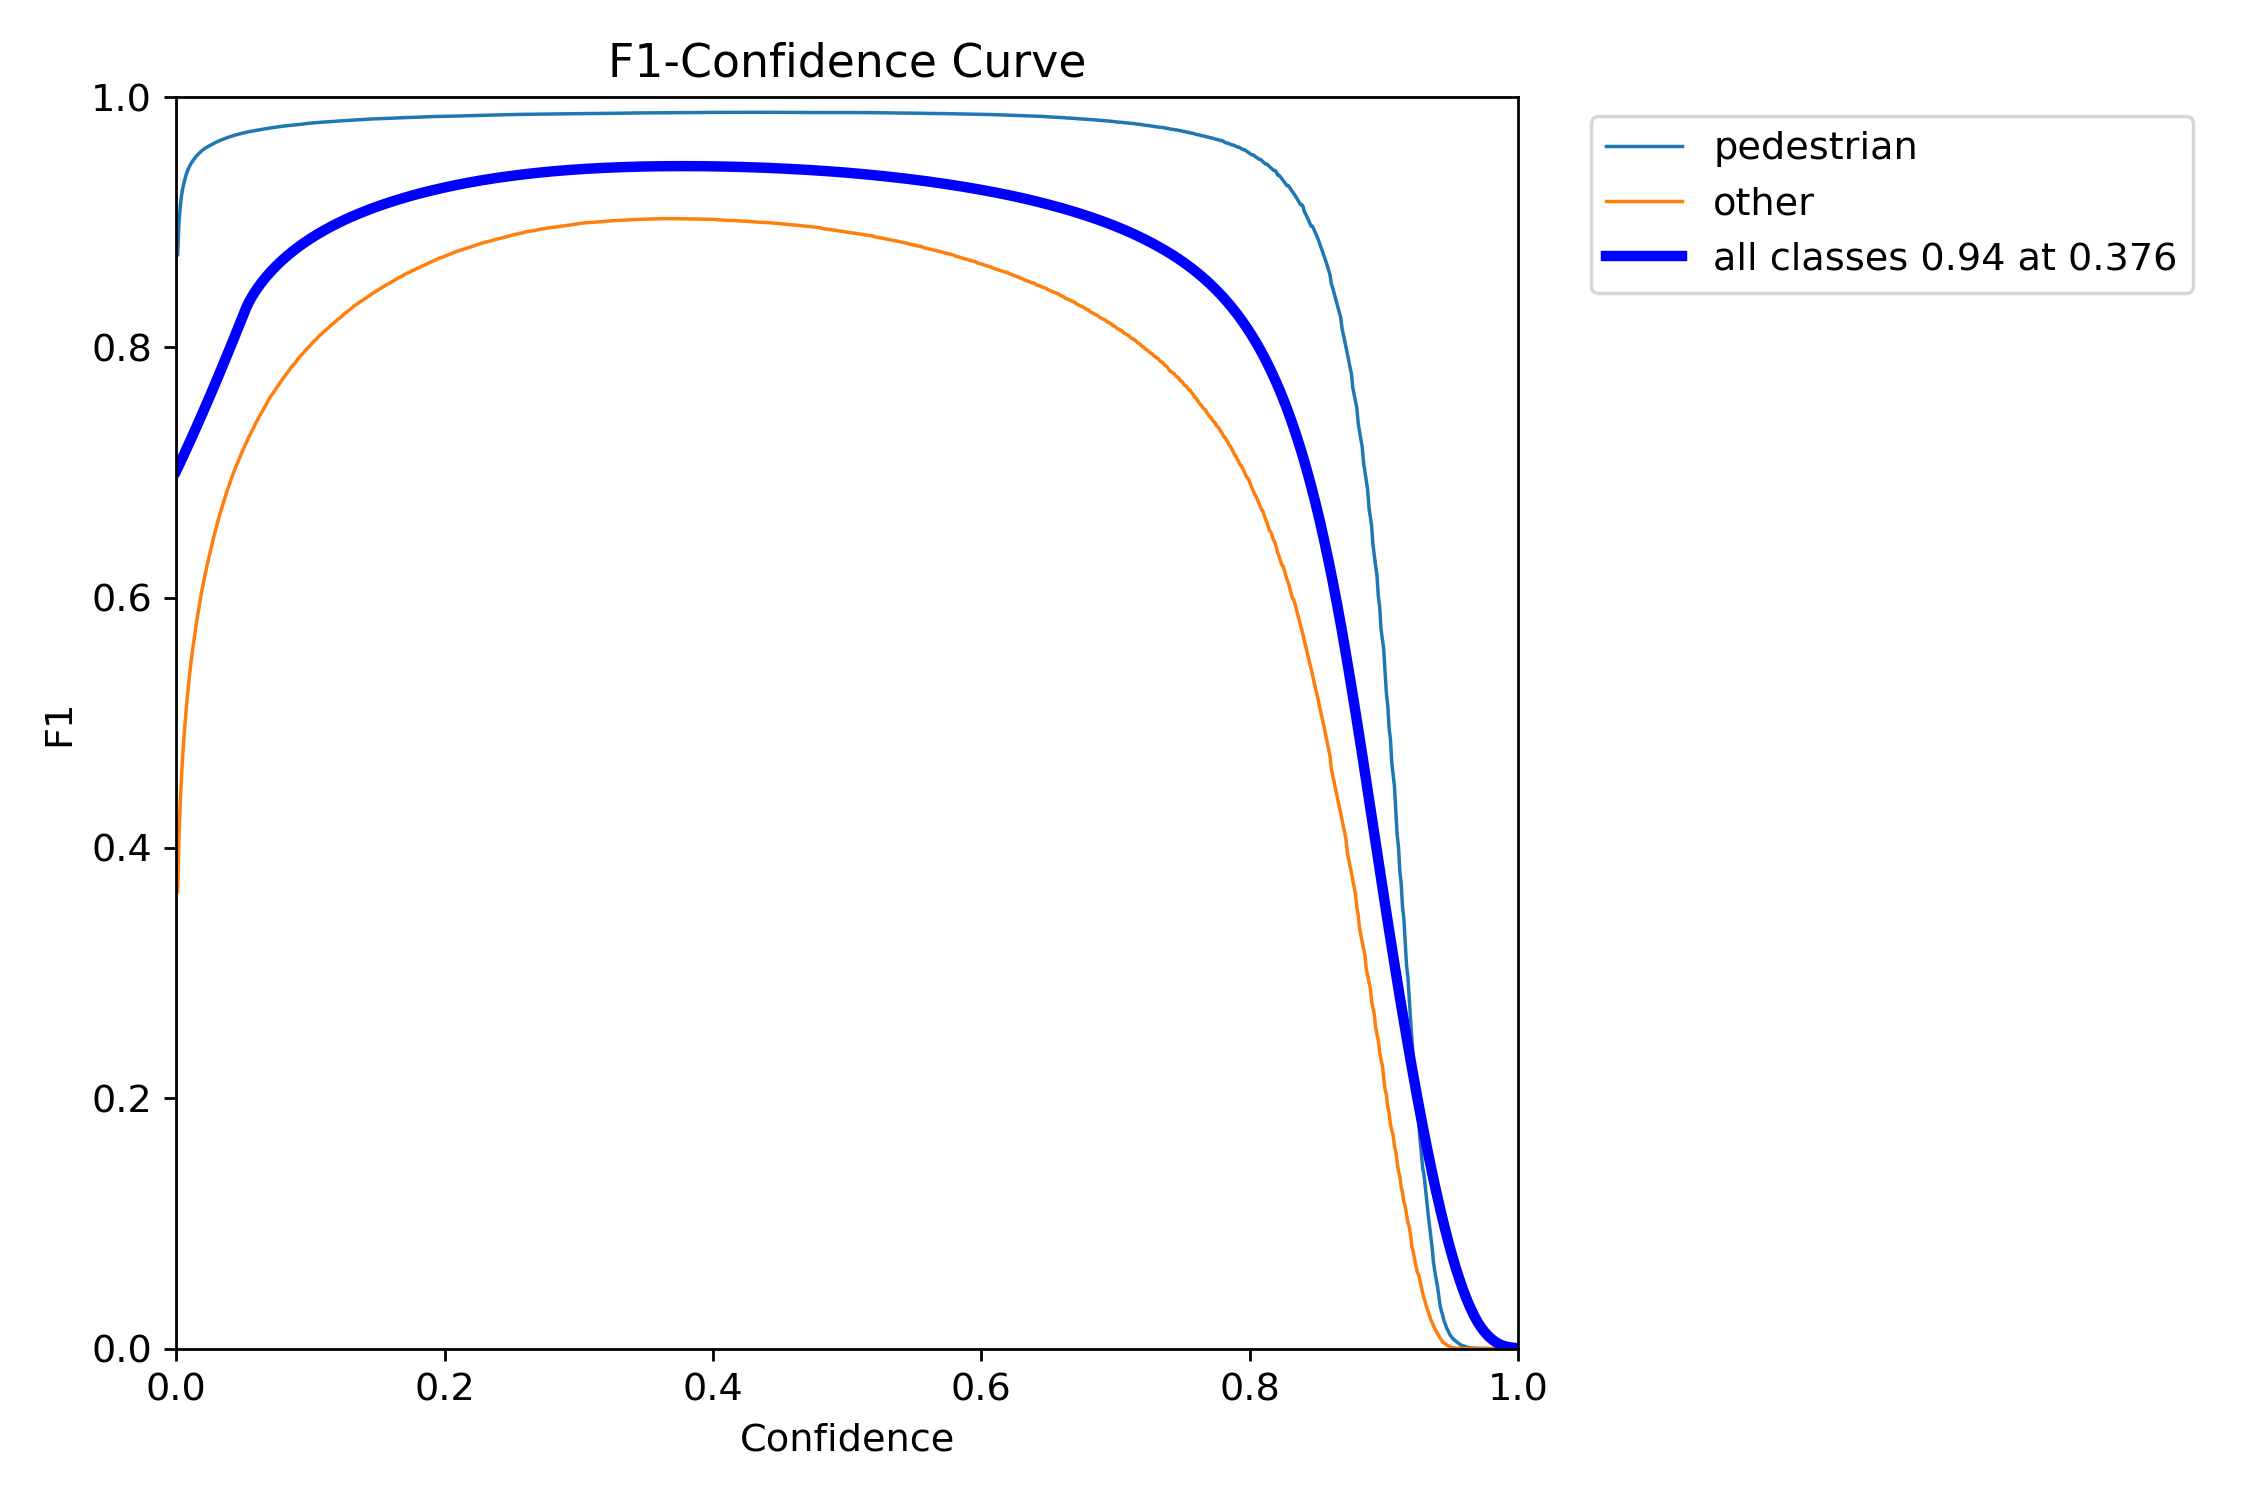

Showing: BoxP_curve.png


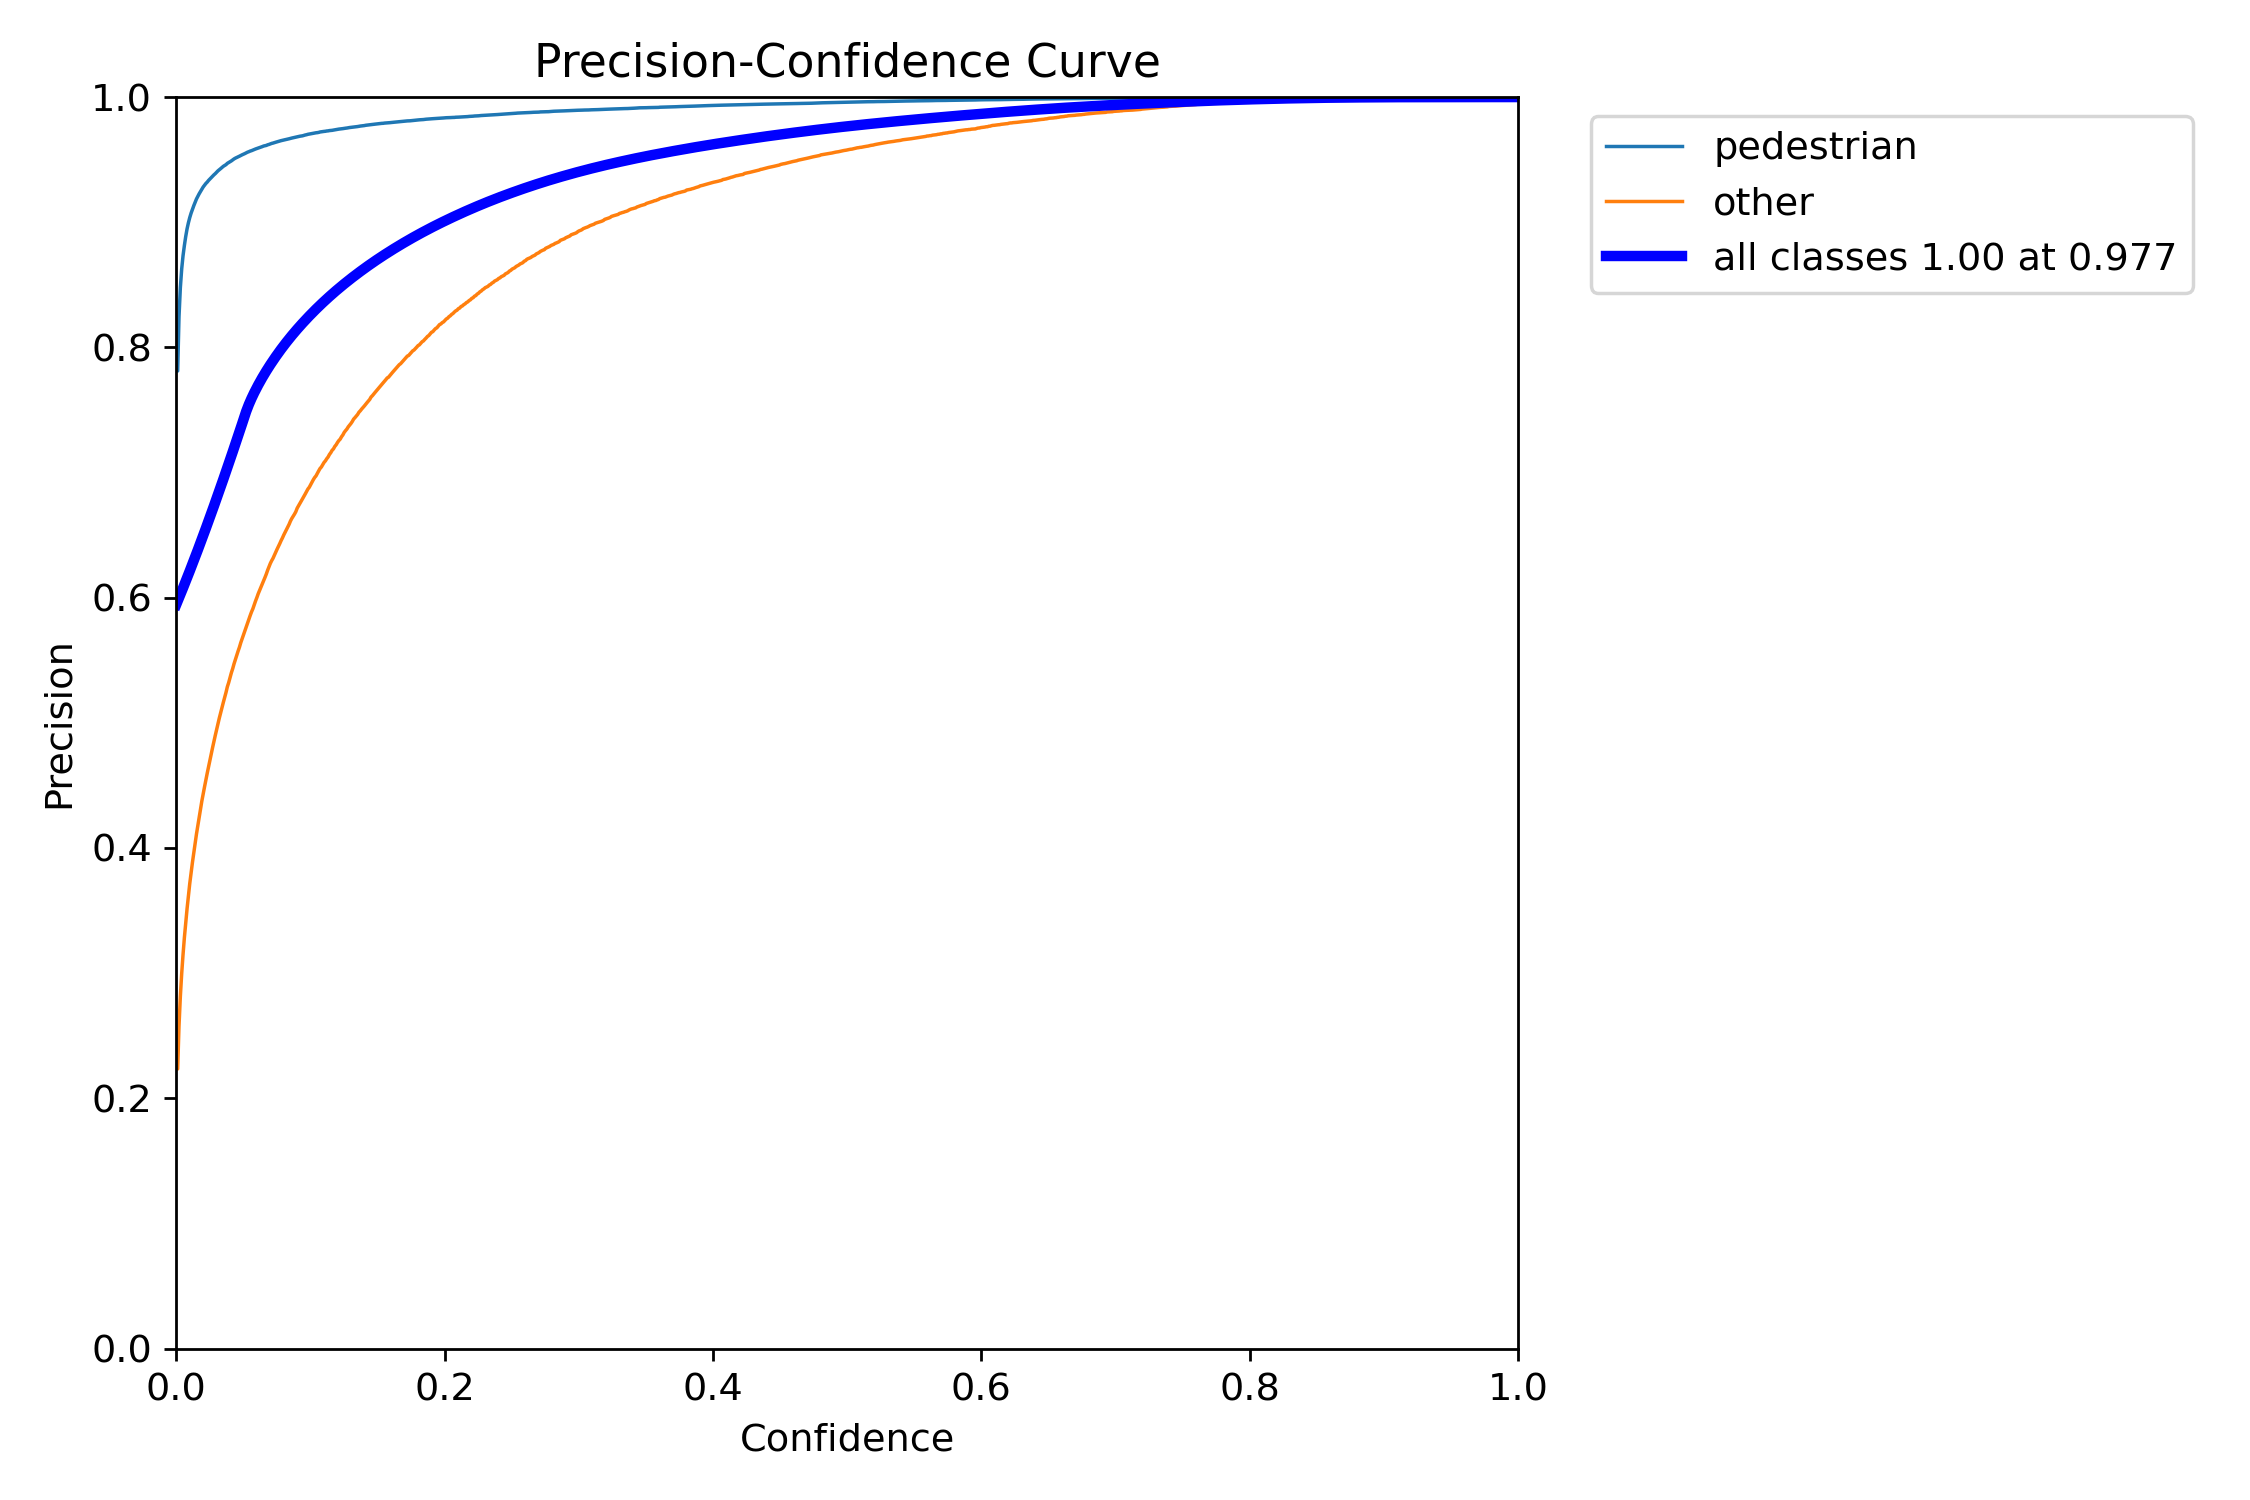

Showing: BoxR_curve.png


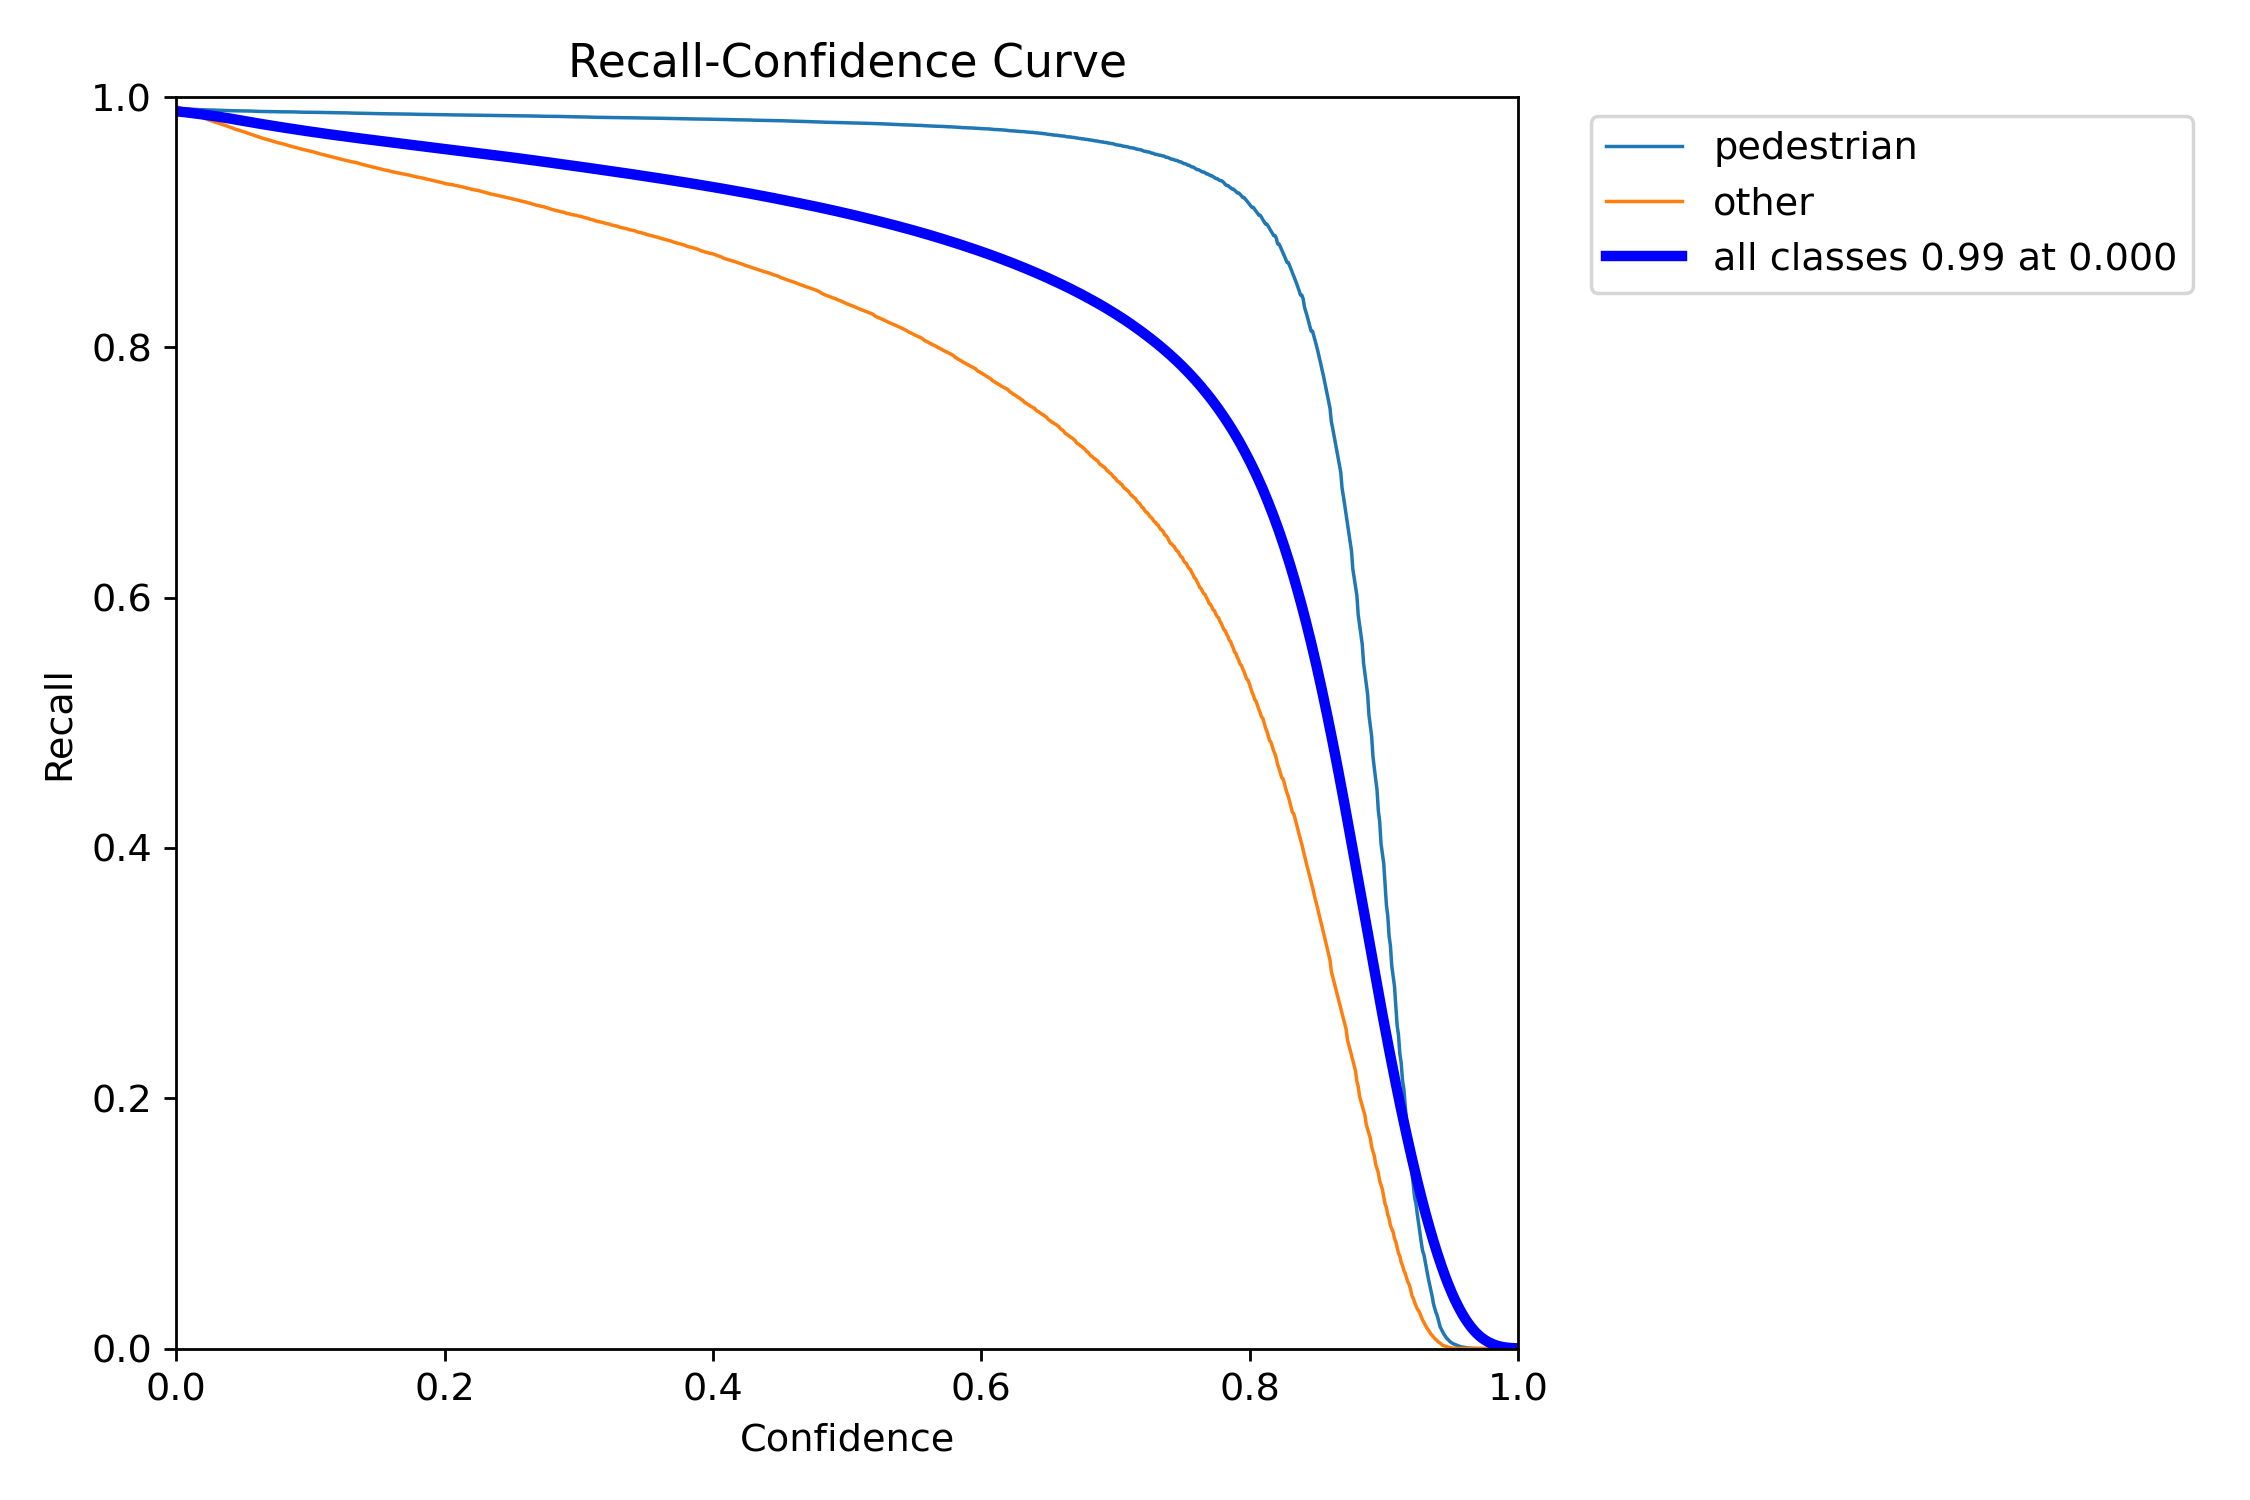

Showing: confusion_matrix_normalized.png


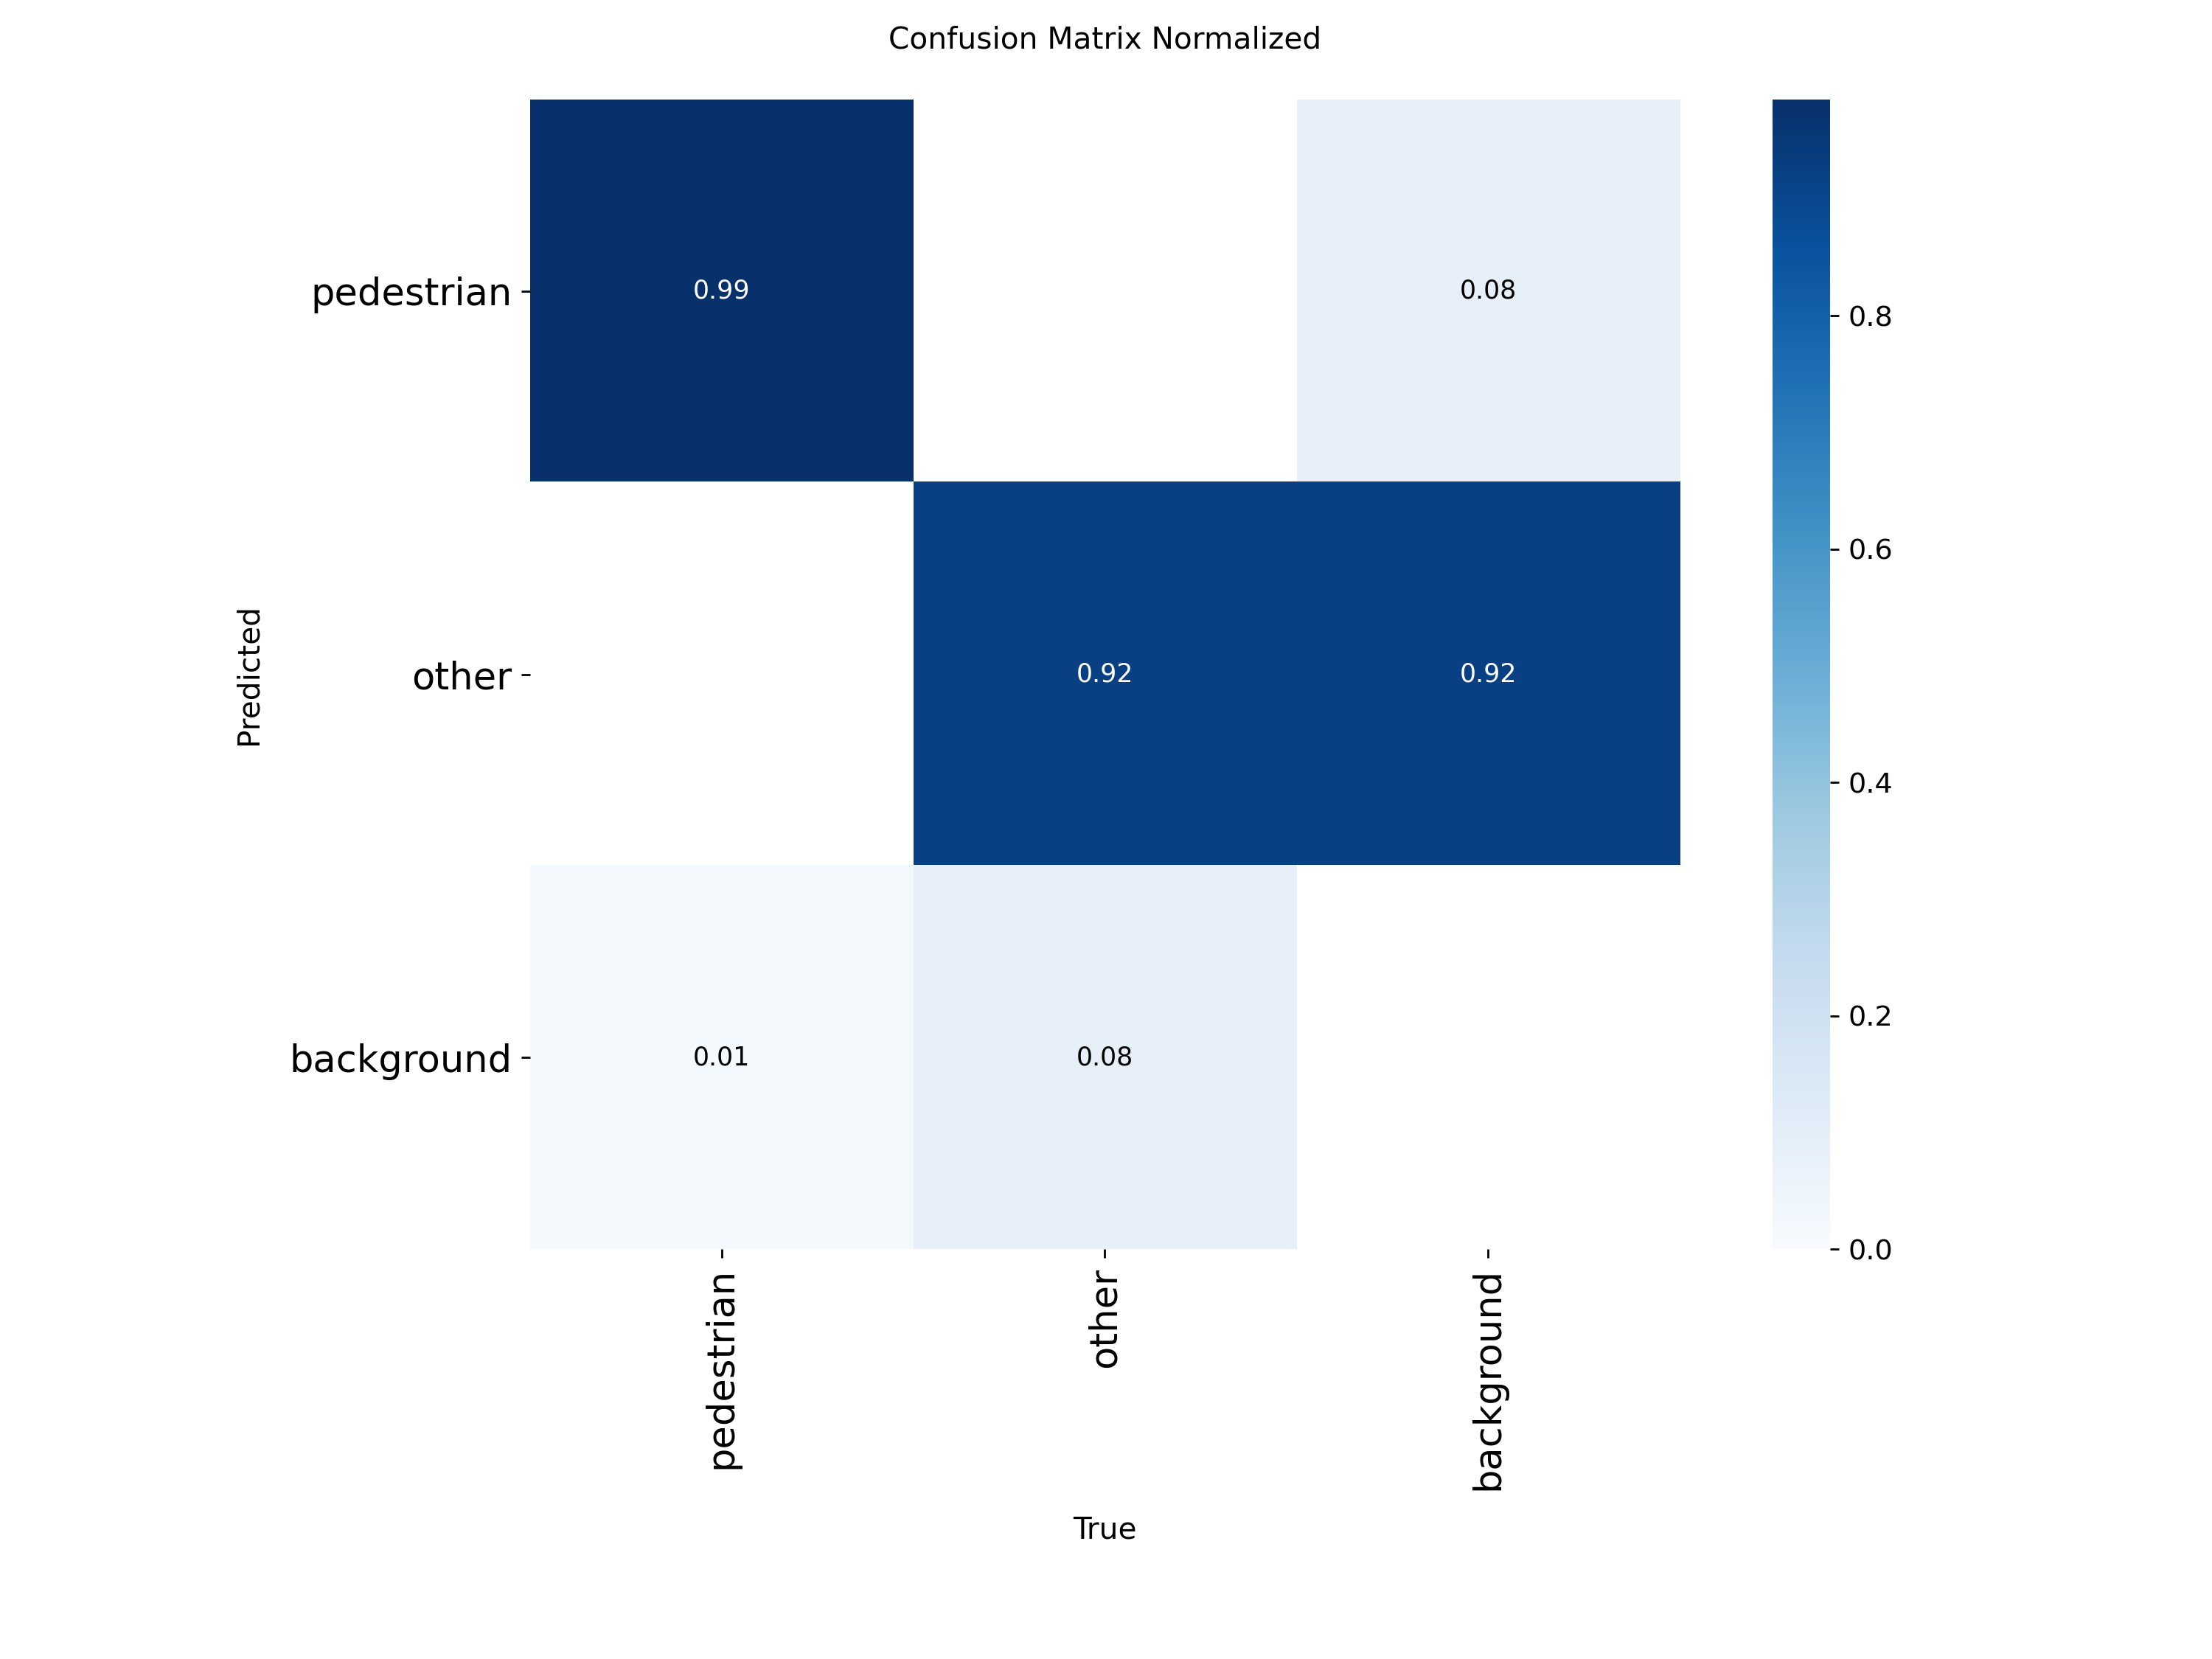

Showing: confusion_matrix.png


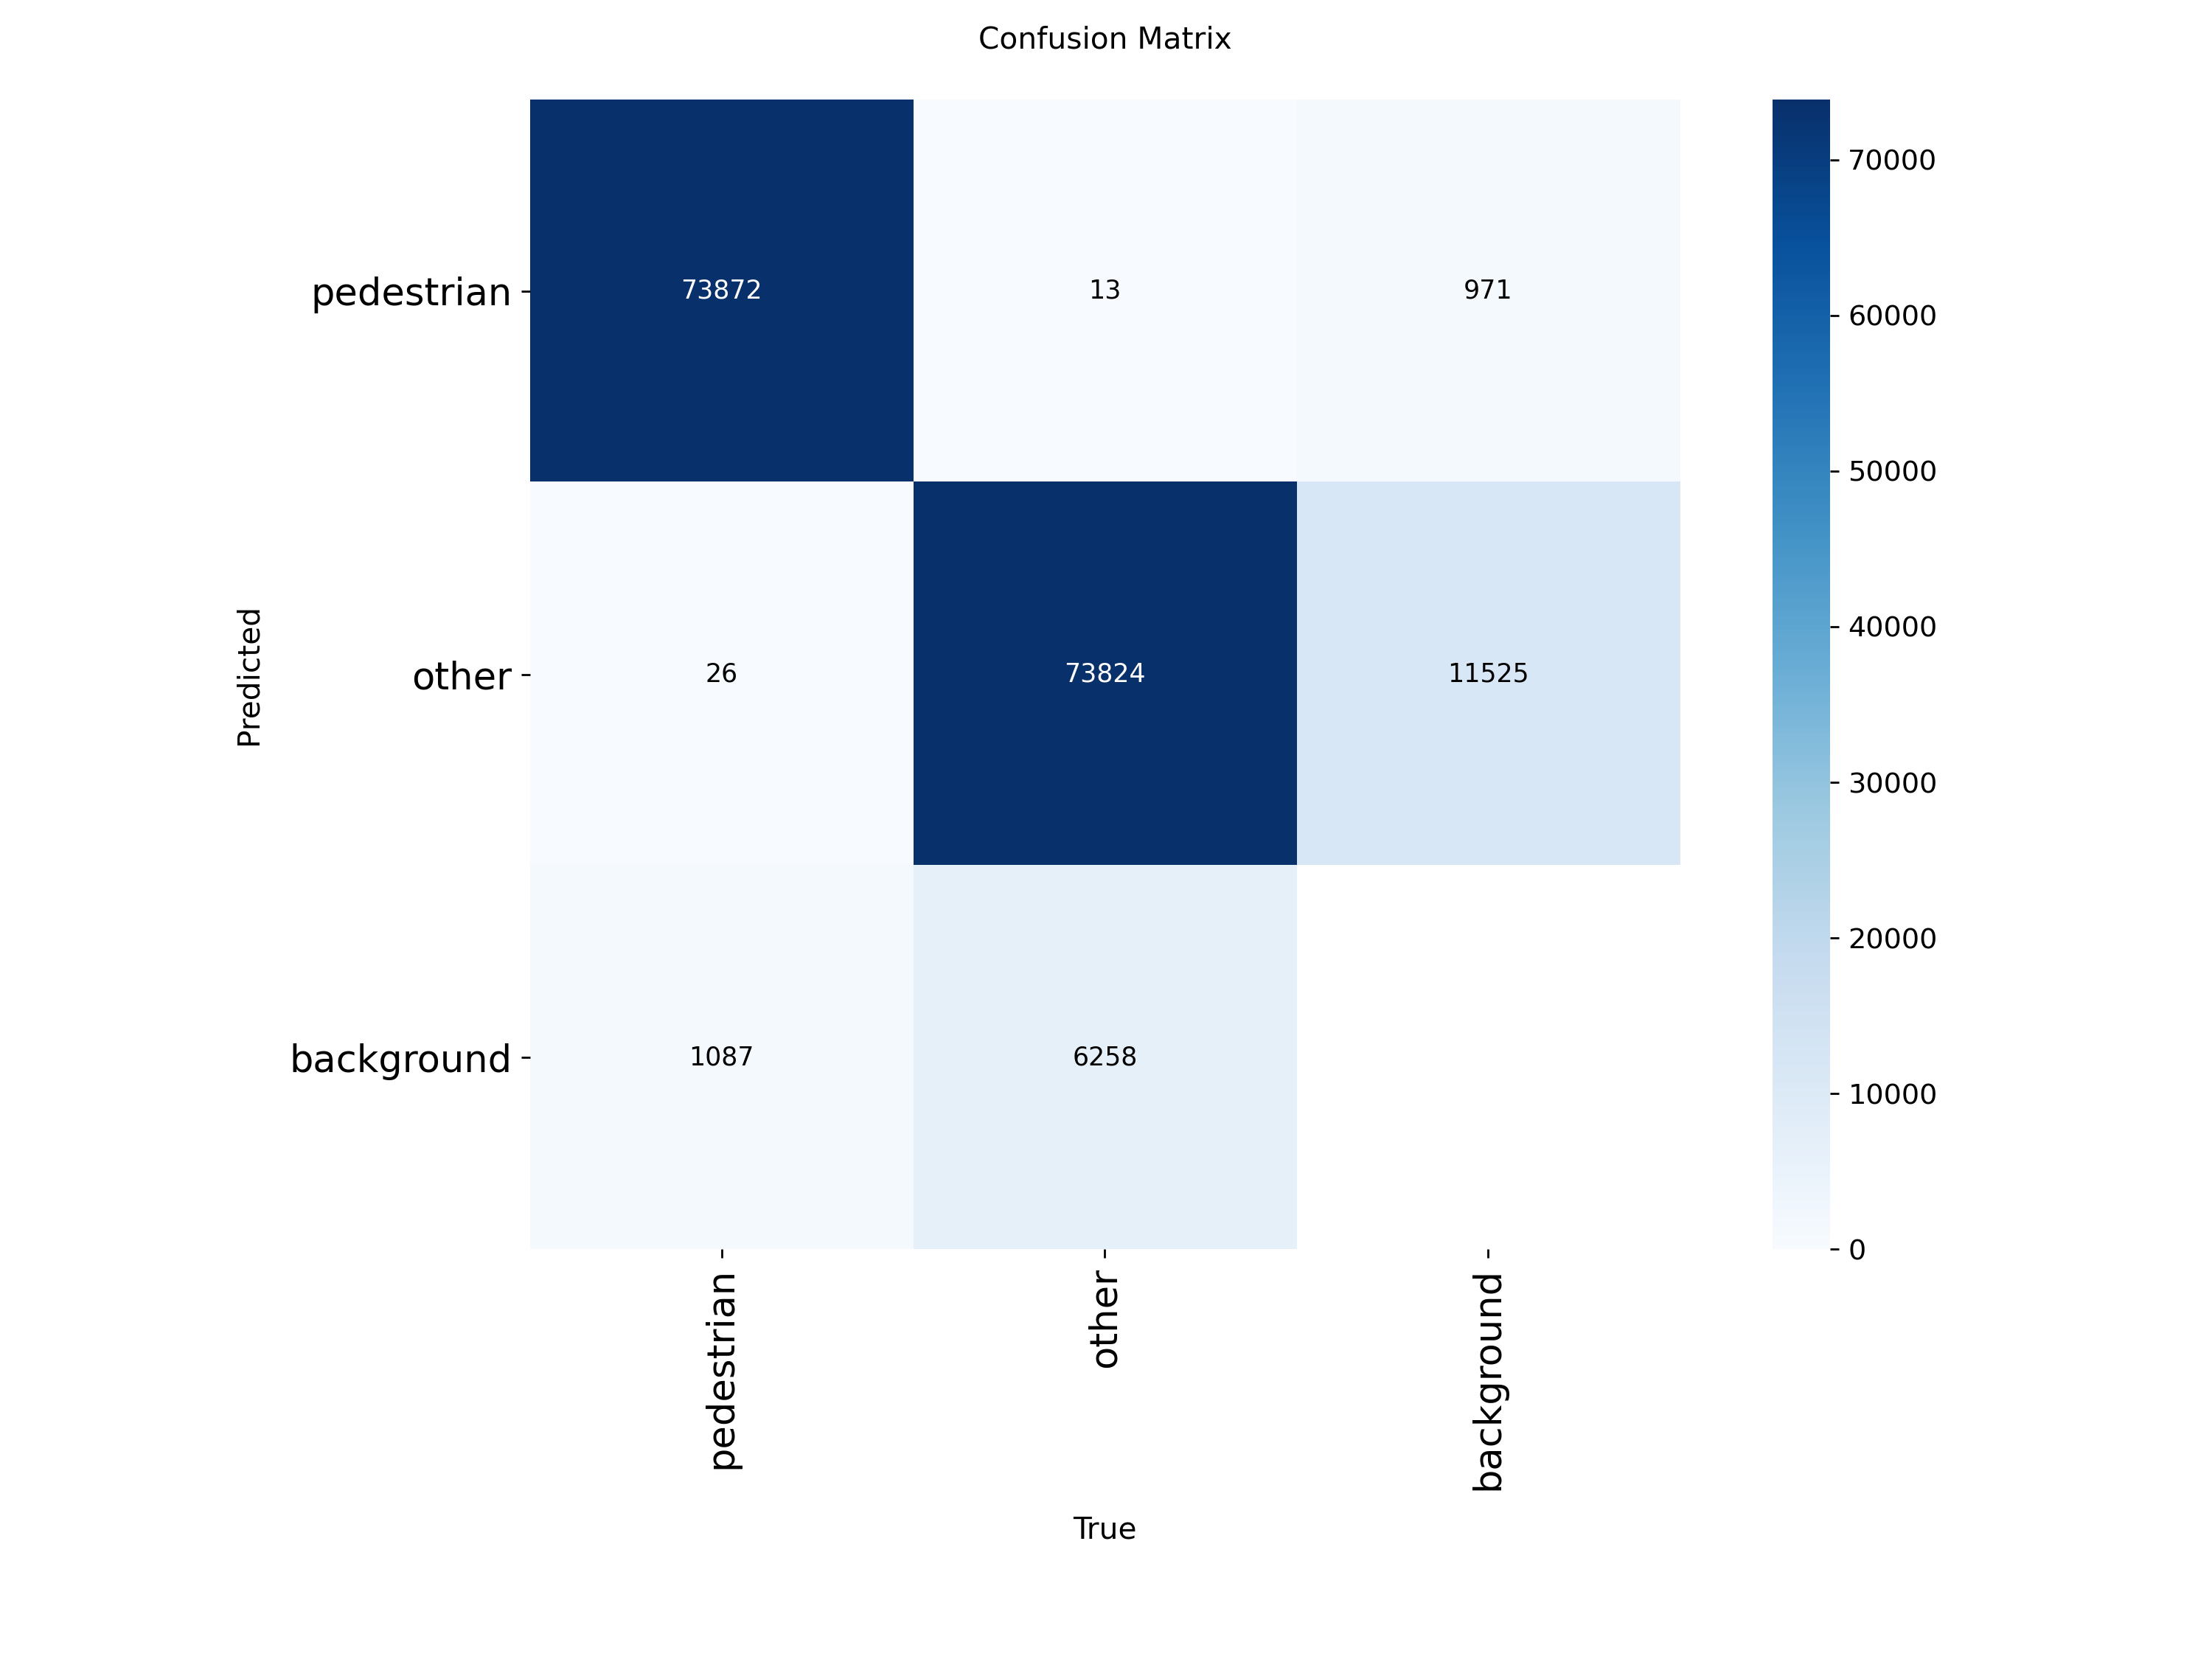

Showing: results.png


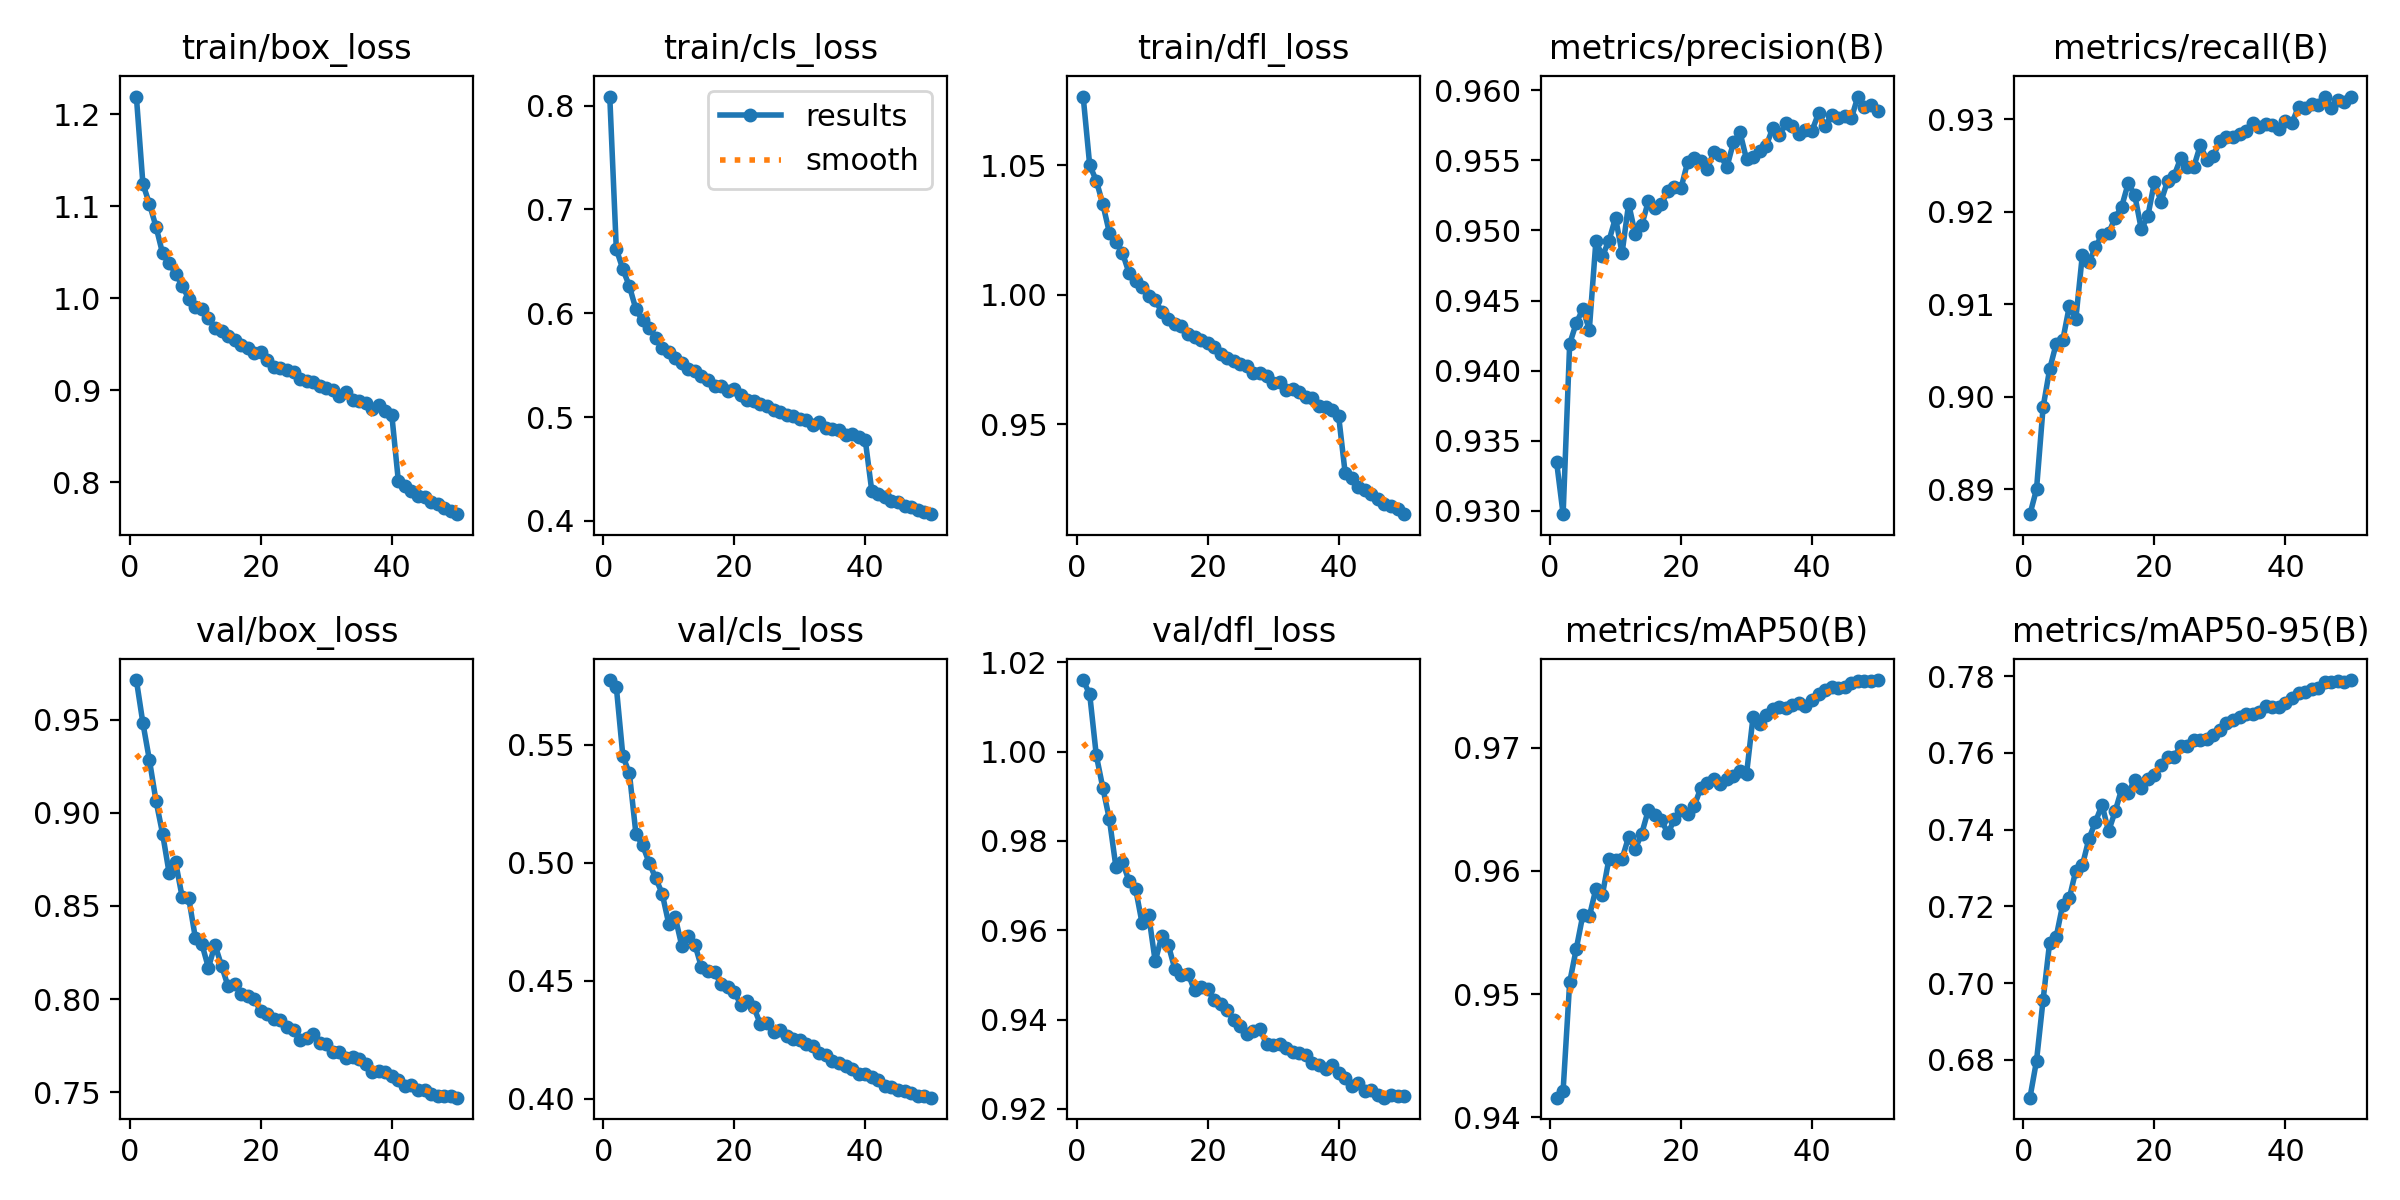

In [ ]:
from IPython.display import Image, display
import os

for file in os.listdir(RUN_DIR):
    if file.endswith(".png"):
        print("Showing:", file)
        display(Image(filename=os.path.join(RUN_DIR, file)))

In [ ]:
import pandas as pd

csv_path = os.path.join(RUN_DIR, "results.csv")
df = pd.read_csv(csv_path)

df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,276.593,1.21934,0.80879,1.07661,0.93351,0.88728,0.94158,0.67013,0.97117,0.57749,1.01601,0.000555,0.000555,0.000555
1,2,545.846,1.12426,0.66176,1.05003,0.92977,0.88997,0.94216,0.67974,0.94802,0.57458,1.01280,0.001088,0.001088,0.001088
2,3,812.548,1.10248,0.64243,1.04417,0.94191,0.89883,0.95096,0.69556,0.92809,0.54529,0.99920,0.001600,0.001600,0.001600
3,4,1079.480,1.07776,0.62598,1.03503,0.94338,0.90295,0.95365,0.71052,0.90629,0.53793,0.99190,0.001568,0.001568,0.001568
4,5,1345.330,1.04884,0.60368,1.02404,0.94439,0.90572,0.95639,0.71200,0.88879,0.51212,0.98486,0.001535,0.001535,0.001535


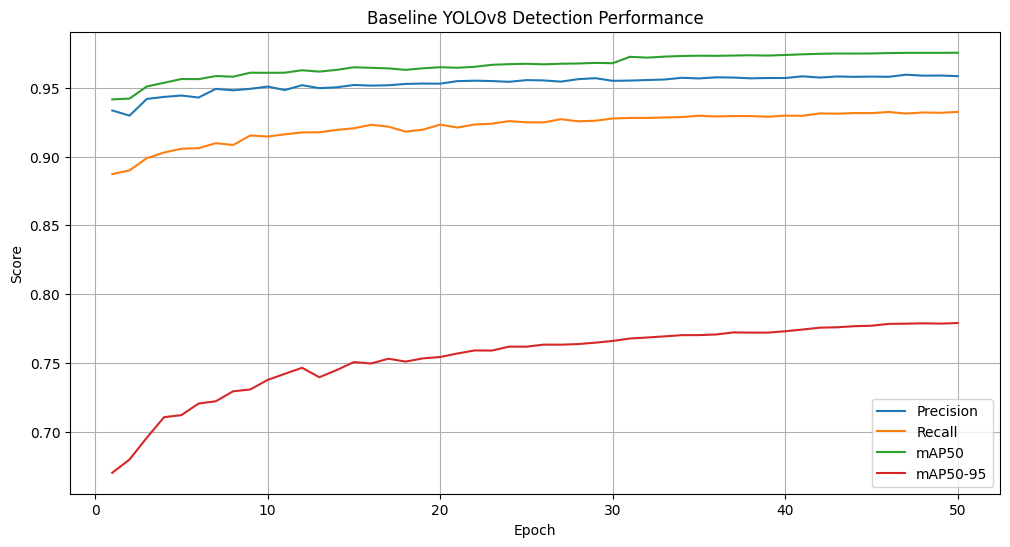

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Baseline YOLOv8 Detection Performance")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_row = df.loc[df["metrics/mAP50(B)"].idxmax()]

import pandas as pd

summary = pd.DataFrame([{
    "Experiment": "Baseline",
    "Dataset": "Original CityPersons",
    "Model": "YOLOv8n",
    "Epochs": 50,
    "Best Epoch": int(best_row["epoch"]),
    "Precision": round(best_row["metrics/precision(B)"],3),
    "Recall": round(best_row["metrics/recall(B)"],3),
    "mAP50": round(best_row["metrics/mAP50(B)"],3),
    "mAP50-95": round(best_row["metrics/mAP50-95(B)"],3),
    "Hardware": "Tesla T4 GPU"
}])

summary

In [ ]:
summary.to_csv("/content/drive/MyDrive/final-year-research/outputs/baseline_report.csv", index=False)
print("Baseline report saved to Drive")

Testing the Model using normal (unblurred) data

In [ ]:
import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/final-year-research"
WORK_DIR = "/content/final-year-research"
ZIP_PATH = f"{PROJECT_DIR}/dataset/WilderPerson.zip"

os.makedirs(WORK_DIR, exist_ok=True)
shutil.copy(ZIP_PATH, f"{WORK_DIR}/WilderPerson.zip")
print("Copied zip to Colab VM")

Copied zip to Colab VM


In [ ]:
import zipfile

with zipfile.ZipFile(f"{WORK_DIR}/WilderPerson.zip", 'r') as zip_ref:
    zip_ref.extractall(f"{WORK_DIR}/dataset")

print("Unzipped dataset")

Unzipped dataset


In [ ]:
!ls /content/final-year-research/dataset/

data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


In [ ]:
import yaml

yaml_path_normal = "/content/WilderPerson_normal.yaml"

data = {
    "path": "/content/final-year-research/dataset",  # ORIGINAL dataset path
    "train": "train/images",
    "val": "valid/images",
    "names": {
        0: "pedestrian",
        1: "other"
    }
}

with open(yaml_path_normal, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("Normal dataset YAML ready!")

Normal dataset YAML ready!


In [ ]:
!yolo detect val \
  model="/content/drive/MyDrive/final-year-research/runs/wilderperson_faceblur_research_v1/weights/best.pt" \
  data="/content/WilderPerson_normal.yaml" \
  device=0 \
  project="/content/drive/MyDrive/final-year-research/results/val_results" \
  name="Wilderperson_blurred_model_trained_normal"

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 982.2±410.8 MB/s, size: 46.1 KB)
val: Scanning /content/final-year-research/dataset/valid/labels... 3284 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3284/3284 1.4Kit/s 2.3s
val: New cache created: /content/final-year-research/dataset/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 206/206 3.2it/s 1:05
                   all       3284     155080      0.705      0.409      0.513      0

In [ ]:
!ls /content/drive/MyDrive/final-year-research

dataset   docs	     outputs  runs
datasets  notebooks  results  transformed_datasets
